In [17]:
from scqubits import *
import scqubits.core.units as units
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from qutip import *

(<Figure size 640x480 with 2 Axes>, <Axes: >)

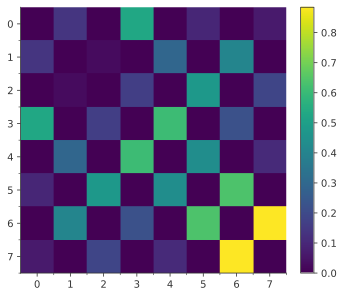

In [12]:
qbt = Fluxonium(EJ = 2.65,
            EC = 0.6,
            EL = 0.13,
            flux = 0,
            cutoff=110,
            truncated_dim  = 8)
qbt.plot_matrixelements('n_operator',evals_count = 8,show3d= False)

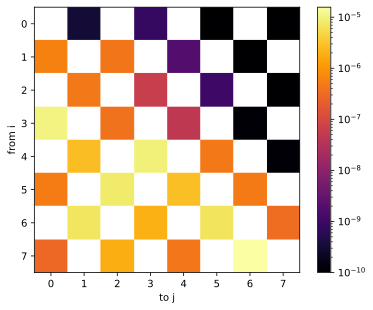

In [14]:

n_levels = 8
transition_rates = np.zeros((n_levels,n_levels))
for i in range(n_levels):
    for j in range(n_levels):
        if i == j:
            transition_rates[i,j] = 1e-20
        else:
            transition_rates[i,j] = qbt.t1_effective(
                                    common_noise_options = dict(i = i, j = j, total = False,),
                                    get_rate = True,
                                    )
            
        
transition_rates[transition_rates < 1e-19] = np.nan
transition_rates = np.ma.masked_invalid(transition_rates)
        
plt.imshow(transition_rates, norm=LogNorm(vmin=1e-10, vmax=transition_rates.max()), cmap='inferno')
plt.colorbar()
plt.xlabel('to j')
plt.ylabel('from i')
# plt.title('Heatmap in Log Scale')
plt.show()

In [49]:
liovillian = Qobj(dims =  [[[n_levels], [n_levels]], [[n_levels], [n_levels]]])
for i in range(n_levels):
    for j in range(n_levels):
        if not transition_rates.mask[j,i]:        
            liovillian += lindblad_dissipator(
                                    np.sqrt(transition_rates[j,i]) * basis(n_levels,i) * basis(n_levels,j).dag()
                                              )



In [74]:
def plot_decay_of_state(j,tot_time = 1000000):
    tlist = np.linspace(0,tot_time,int(tot_time/100))
    result = mesolve(H = Qobj(qbt.hamiltonian(energy_esys = True)),
                    rho0 = qutip.basis(n_levels,j),
                    c_ops = [liovillian],
                    e_ops = [
                        basis(n_levels,i) * basis(n_levels,i).dag() for i in range(n_levels)
                    ],
                    tlist = tlist,
                    options = Options(store_states=True)
                    )

    for i in range(n_levels):
        if i != j:
            plt.plot(tlist, result.expect[i], label = f"{i}")
        else:
            plt.plot(tlist, 1- result.expect[i], label = f"1-{i}")
    plt.legend()

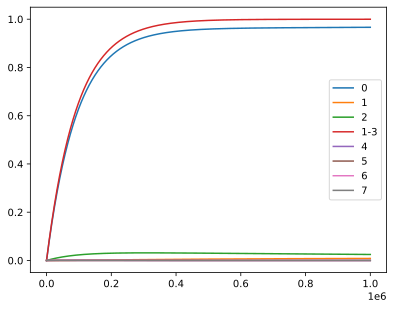

In [76]:
plot_decay_of_state(3)

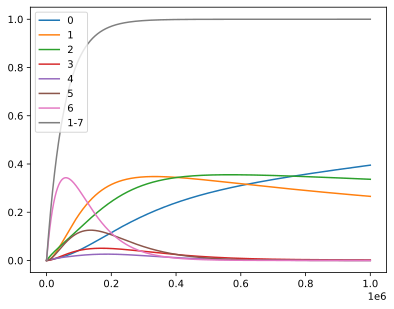

In [75]:
plot_decay_of_state(7)

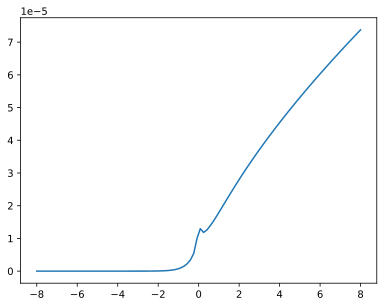

In [28]:
##################################################################
# Plotting the default spectural density
##################################################################

T = 0.015
EC = 0.6
def q_cap_fun(omega):
    return (
        1e6
        * (2 * np.pi * 6e9 / np.abs(units.to_standard_units(omega))) ** 0.7
    )

def calc_therm_ratio(
    omega: float, T: float, omega_in_standard_units: bool = False
) -> float:
    r"""Returns the ratio

    :math:`\beta \omega = \frac{\hbar \omega}{k_B T}`

    after converting `\omega` from system units, to standard units.

    Parameters
    ----------
    omega:
        angular frequency in system units
    T:
        temperature in Kelvin
    omega_in_standard_units:
        is omega given in standard units (i.e. Hz)

    Returns
    -------
    float
    """
    omega = units.to_standard_units(omega) if not omega_in_standard_units else omega
    return (sp.constants.hbar * omega) / (sp.constants.k * T)



def spectral_density(omega):
    therm_ratio = calc_therm_ratio(omega, T)
    s = (
        2
        * 8
        * EC
        / q_cap_fun(omega)
        * (1 / np.tanh(0.5 * np.abs(therm_ratio)))
        / (1 + np.exp(-therm_ratio))
    )
    s *= (
        2 * np.pi
    )  # We assume that system energies are given in units of frequency
    return s

o_list = np.linspace(-8,8,100)
density = spectral_density(2 * np.pi *o_list)
import matplotlib.pyplot as plt
plt.plot(o_list,density)